# BTC Price Analysis and Visualization
This notebook analyzes the historical BTC/USD data downloaded from Kaggle.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load data
data_path = os.path.join('data', 'btcusdt_analysis_data.csv')
if not os.path.exists(data_path):
    print("Error: Data file not found. Please run 'python download_data.py' first.")
else:
    df = pd.read_csv(data_path)
    # Convert Timestamp to Datetime
    df['Datetime'] = pd.to_datetime(df['Timestamp'], unit='s')
    df.set_index('Datetime', inplace=True)
    print(f"Data Loaded: {len(df)} rows.")
    print(df.head())

Data Loaded: 7480480 rows.
                        Timestamp  Open  High   Low  Close  Volume
Datetime                                                          
2012-01-01 10:01:00  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2012-01-01 10:02:00  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2012-01-01 10:03:00  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2012-01-01 10:04:00  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2012-01-01 10:05:00  1.325412e+09  4.58  4.58  4.58   4.58     0.0


## Basic Statistics
Analyzing the key metrics of the dataset.

In [3]:
# Summary statistics
df.describe()

,Timestamp,Open,High,Low,Close,Volume
count,7.480480e+06,7.480480e+06,7.480480e+06,7.480480e+06,7.480480e+06,7.480480e+06
mean,1.549831e+09,2.254168e+04,2.254970e+04,2.253348e+04,2.254169e+04,5.067162e+00
std,1.295738e+08,3.087505e+04,3.088347e+04,3.086655e+04,3.087506e+04,2.184385e+01
min,1.325412e+09,3.800000e+00,3.800000e+00,3.800000e+00,3.800000e+00,0.000000e+00
25%,1.437619e+09,4.500000e+02,4.500700e+02,4.499800e+02,4.500000e+02,2.097203e-02
50%,1.549826e+09,7.611245e+03,7.616680e+03,7.605980e+03,7.611300e+03,4.573234e-01
75%,1.662034e+09,3.522100e+04,3.524300e+04,3.519744e+04,3.522110e+04,2.869644e+00
max,1.774310e+09,1.262020e+05,1.262720e+05,1.261580e+05,1.262020e+05,5.853852e+03


## Price Over Time
Visualizing the closing price over the entire period.

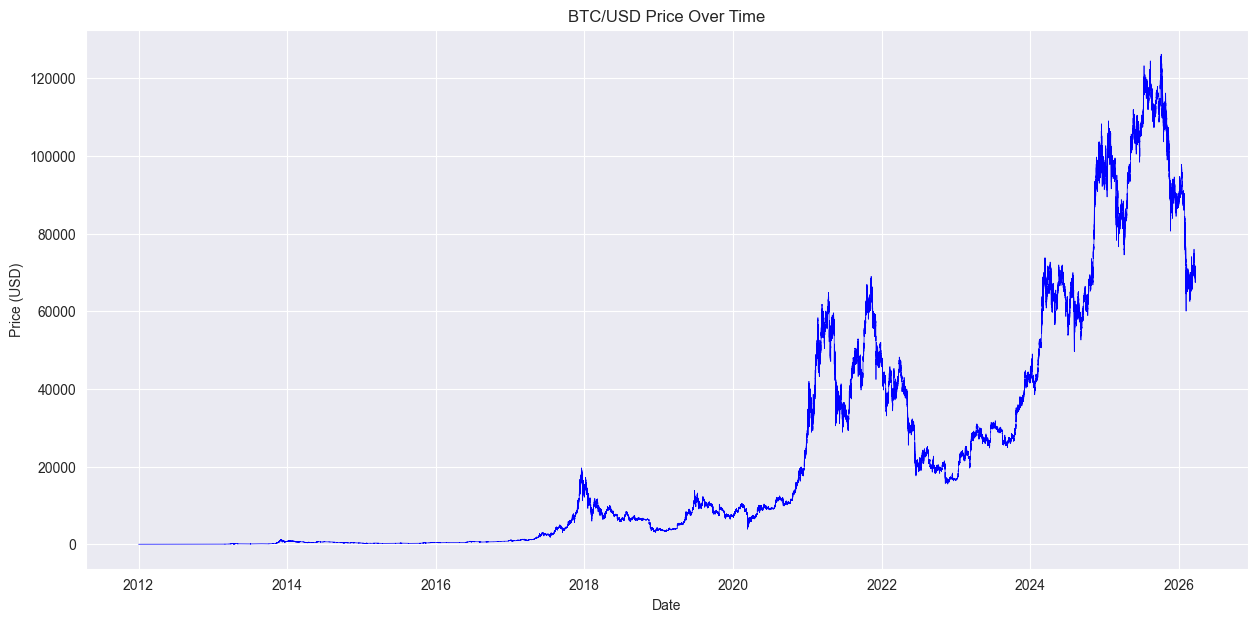

In [4]:
# Plotting Closing Price
plt.figure(figsize=(15, 7))
plt.plot(df['Close'], color='blue', linewidth=0.5)
plt.title('BTC/USD Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

## 2021 Price Movement
Zooming into 2021 to see more detail.

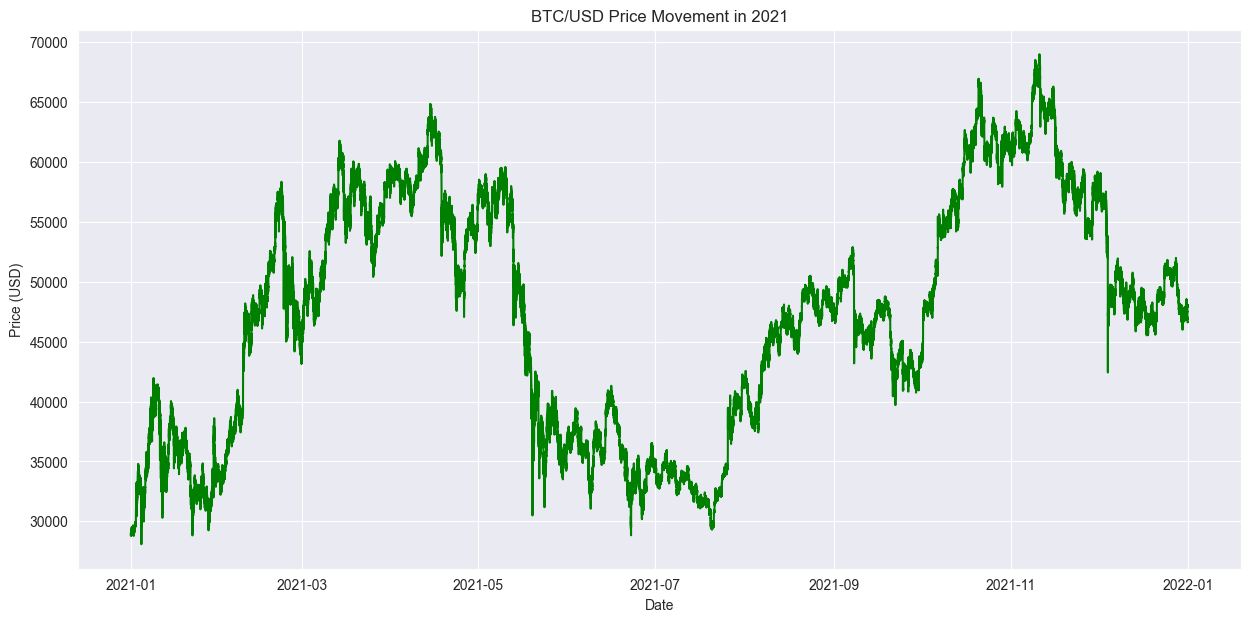

In [5]:
# 2021 Price Data
df_2021 = df[df.index.year == 2021]
plt.figure(figsize=(15, 7))
plt.plot(df_2021['Close'], color='green')
plt.title('BTC/USD Price Movement in 2021')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

## Volume vs. Price
Comparing trading volume with price movements.

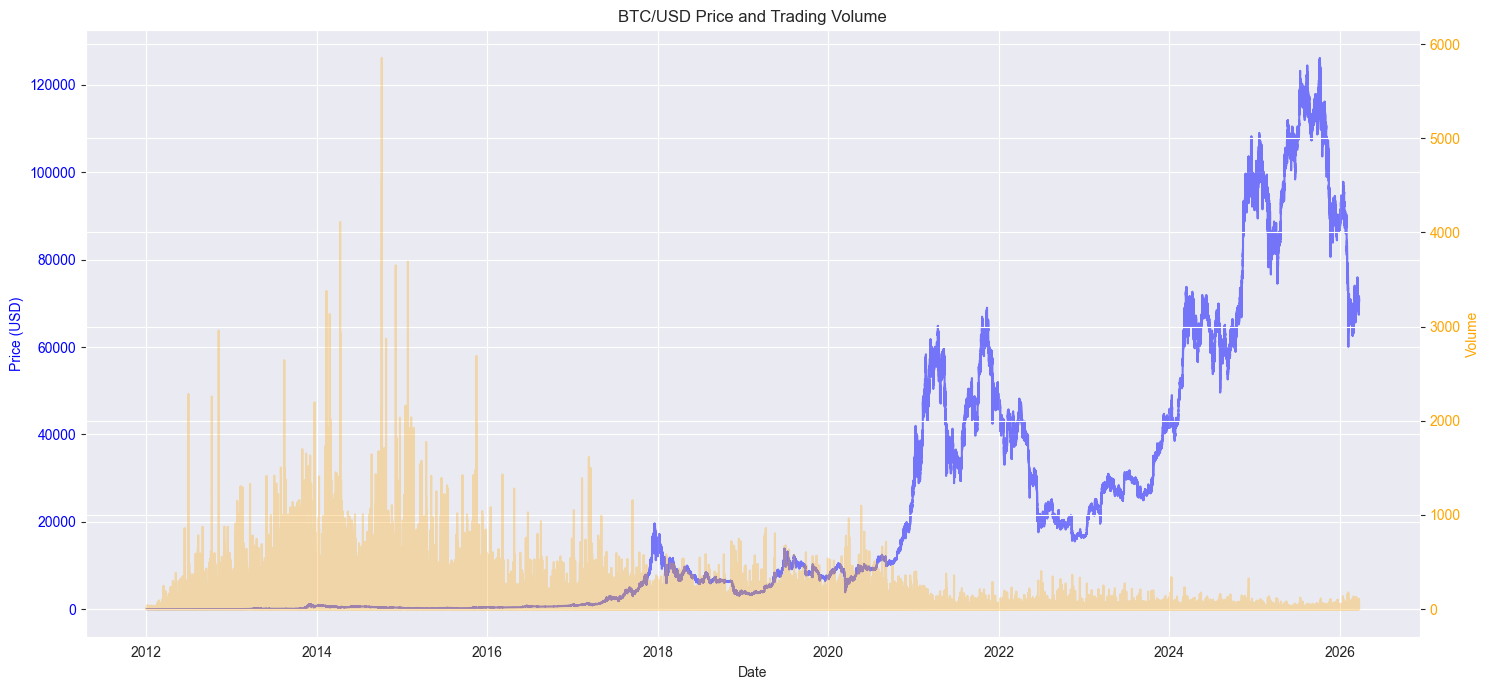

In [6]:
# Volume and Price plot
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.set_xlabel('Date')
ax1.set_ylabel('Price (USD)', color='blue')
ax1.plot(df['Close'], color='blue', alpha=0.5, label='Price')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Volume', color='orange')
ax2.plot(df['Volume'], color='orange', alpha=0.3, label='Volume')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('BTC/USD Price and Trading Volume')
fig.tight_layout()
plt.show()

## Moving Averages
Adding moving averages to identify trends.

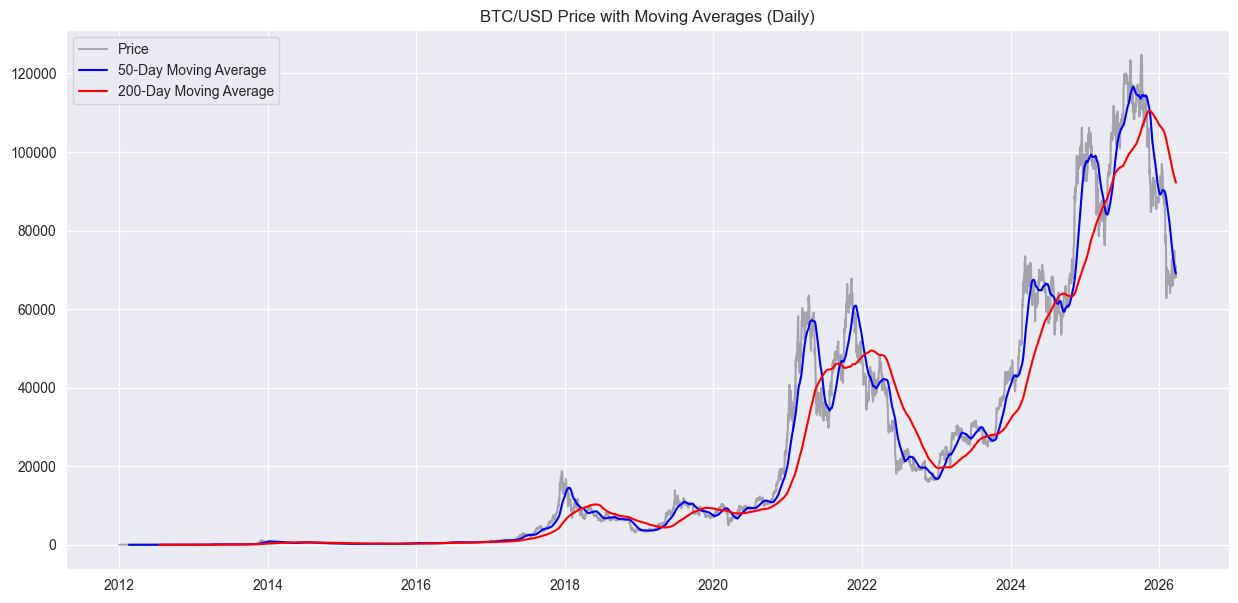

In [7]:
# Calculating Moving Averages (using daily resample for smoother lines)
df_daily = df.resample('D').last()
df_daily['MA50'] = df_daily['Close'].rolling(window=50).mean()
df_daily['MA200'] = df_daily['Close'].rolling(window=200).mean()

plt.figure(figsize=(15, 7))
plt.plot(df_daily['Close'], label='Price', color='black', alpha=0.3)
plt.plot(df_daily['MA50'], label='50-Day Moving Average', color='blue')
plt.plot(df_daily['MA200'], label='200-Day Moving Average', color='red')
plt.title('BTC/USD Price with Moving Averages (Daily)')
plt.legend()
plt.grid(True)
plt.show()